In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("../data/processed/nba_stats_clean.csv")

print(df.shape)
print(df.columns.tolist())

(6708, 29)
['season', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs', 'mp', 'per', 'ts_percent', 'x3p_ar', 'f_tr', 'orb_percent', 'drb_percent', 'trb_percent', 'ast_percent', 'stl_percent', 'blk_percent', 'tov_percent', 'usg_percent', 'ows', 'dws', 'ws', 'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp']


In [3]:
global_stats = [
    "usg_percent",
    "ts_percent",
    "x3p_ar",
    "f_tr",
    "ast_percent",
    "trb_percent",
    "stl_percent",
    "blk_percent",
    "tov_percent",
    "bpm",
    "vorp"
]

X_global = df[global_stats]

In [4]:
scaler = StandardScaler()
X_global_scaled = scaler.fit_transform(X_global)

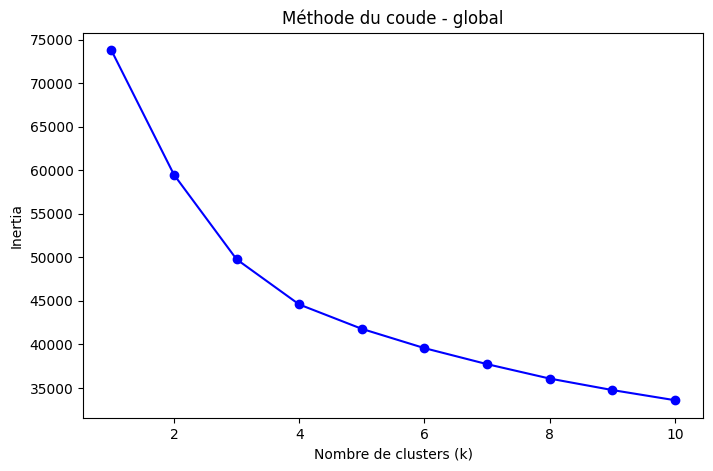

In [5]:
inertia_list = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(X_global_scaled)
    inertia_list.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_list, 'o-', color='blue')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Méthode du coude - global")
plt.show()

In [6]:
inertia_df = pd.DataFrame({'k': k_values, 'inertia': inertia_list})
inertia_df

,k,inertia
0,1,73788.000000
1,2,59492.523411
2,3,49771.424580
3,4,44583.788984
4,5,41783.675840
5,6,39568.071402
6,7,37728.564693
7,8,36072.307457
8,9,34753.675955
9,10,33585.874479


In [7]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_global_scaled)
    score = silhouette_score(X_global_scaled, labels)
    sil_scores.append(score)

sil_df = pd.DataFrame({'k': range(2,11), 'silhouette_score': sil_scores})
sil_df

,k,silhouette_score
0,2,0.232394
1,3,0.232988
2,4,0.180499
3,5,0.143786
4,6,0.131478
5,7,0.124089
6,8,0.127372
7,9,0.128676
8,10,0.122084
